In [2]:
import pandas as pd
df = pd.read_csv("D:\\Pasan\\SLIIT\\Data\\diabetes+130-us+hospitals+for+years+1999-2008\\diabetic_data.CSV")
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.replace("?", pd.NA, inplace=True)
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [4]:
df.drop(columns=["encounter_id"], inplace=True)
df.drop(columns=['patient_nbr'], inplace=True)

In [8]:
df['race'].fillna(df['race'].mode()[0], inplace=True)
df['medical_specialty'].fillna("Unknown", inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_19092\2305405255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna(df['race'].mode()[0], inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_19092\2305405255.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [9]:
df['readmitted'] = df['readmitted'].replace({
    'NO':0,
    '>30':0,
    '<30':1
})

C:\Users\HP\AppData\Local\Temp\ipykernel_19092\499981298.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({


In [5]:
from sklearn.preprocessing import LabelEncoder 

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col])

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [13]:
from sklearn.model_selection import train_test_split

x = df.drop('readmitted', axis=1)
y = df['readmitted']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(x_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report

print('Accuracy:', accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8869509678687236
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.38      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.63      0.50      0.48     20354
weighted avg       0.83      0.89      0.84     20354



In [22]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_pred = knn.predict(x_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8792374963152206
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18069
           1       0.26      0.04      0.07      2285

    accuracy                           0.88     20354
   macro avg       0.57      0.51      0.50     20354
weighted avg       0.82      0.88      0.84     20354



In [29]:
from sklearn.metrics import accuracy_score

for k in range(1,15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    print(k, accuracy_score(y_test, y_pred))

1 0.813107988601749
2 0.8791883659231601
3 0.8647440306573646
4 0.8835118404244866
5 0.8792374963152206
6 0.8855753168910288
7 0.8842487963053945
8 0.8869509678687236
9 0.8864596639481183
10 0.8874914021813894
11 0.8867053159084209
12 0.8874914021813894
13 0.887638793357571
14 0.8878844453178736


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
    )

rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred = rf.predict(x_test)

In [34]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8878353149258131
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.53      0.01      0.01      2285

    accuracy                           0.89     20354
   macro avg       0.71      0.50      0.48     20354
weighted avg       0.85      0.89      0.84     20354



In [35]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[18055    14]
 [ 2269    16]]


In [38]:
!pip install tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=20, batch_size=32)
model.evaluate(x_test, y_test)

Epoch 1/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8872 - loss: 0.3441
Epoch 2/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8886 - loss: 0.3362
Epoch 3/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8888 - loss: 0.3339
Epoch 4/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8888 - loss: 0.3326
Epoch 5/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8889 - loss: 0.3314
Epoch 6/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8889 - loss: 0.3300
Epoch 7/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8891 - loss: 0.3291
Epoch 8/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8891 - loss: 0.3280
Epoch 9/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8895 - loss: 0.3266
Epoch 10/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8895 - loss: 0.3255
Epoch 11/20
2545/2545 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8896 - loss: 0.3241
Epoch 12/20
2545/25

[0.35251230001449585, 0.885526180267334]

In [39]:
loss, accuracy = model.evaluate(x_test, y_test)

print('Test Accuracy', accuracy)

637/637 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8855 - loss: 0.3525
Test Accuracy 0.885526180267334


In [47]:
x = df

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [43]:
clusters = kmeans.labels_

df['Cluster'] = clusters

In [44]:
print(df['Cluster'].value_counts())

Cluster
1    48460
0    44927
2     8379
Name: count, dtype: int64


In [45]:
print(kmeans.cluster_centers_)

[[ 7.00831182e-03  1.67066188e-02 -1.28649700e-02 -5.38204351e-02
  -1.64571482e-01 -5.29473689e-03 -2.02376748e-01  2.30028125e-01
  -1.57142409e-01  1.96358392e-02  1.82867314e-01  7.49064118e-02
   3.75346342e-01  3.37106587e-02  5.34752598e-02  4.97390134e-02
  -4.25744361e-02  1.57305340e-02 -2.04163458e-03  1.32503150e-01
   2.04133286e-01 -1.46883768e-01  3.38512036e-01  9.14724755e-02
   6.52797918e-02 -8.88963524e-03  1.46995607e-01  3.95798841e-03
   1.84283076e-01  1.67034652e-01 -2.44335672e-04  2.10048694e-01
   1.99793819e-01  4.91063011e-02  1.36249056e-02  2.76047860e-03
   3.51818611e-04  0.00000000e+00  0.00000000e+00  2.00156691e-01
   5.28725197e-02  1.23042882e-02 -3.13473463e-03  5.59746840e-03
  -3.13473463e-03 -9.39638389e-01  5.45694985e-01  3.94438326e-02]
 [-4.81197922e-02 -1.93940030e-02 -2.61503450e-03  3.14159227e-02
  -2.18329735e-01 -1.55682213e-02 -2.03585820e-01 -2.12106401e-01
   3.40490777e-02  2.65033602e-02 -1.19872760e-01 -6.34306476e-02
  -3.5595

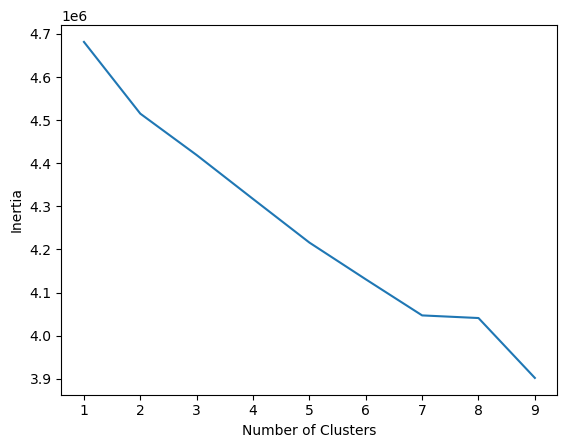

In [46]:
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

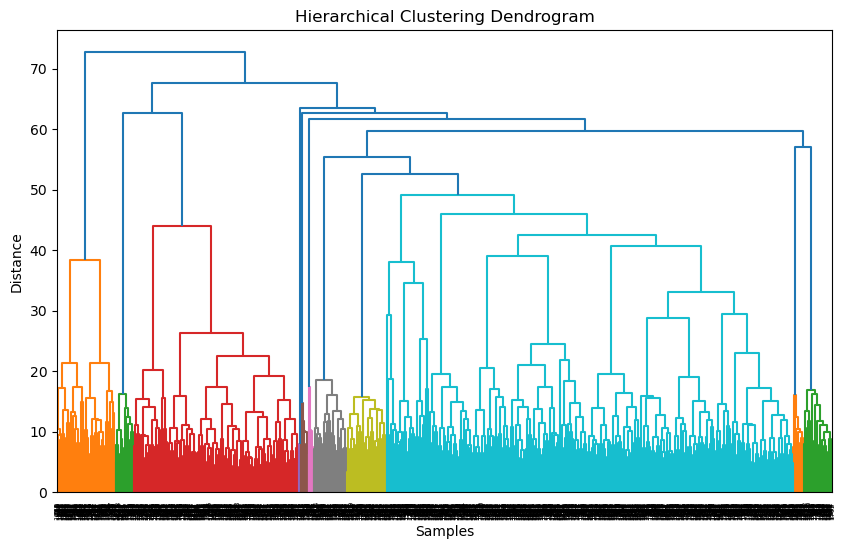

In [9]:
sample_df = df.sample(2000)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(sample_df)

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [13]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = hc.fit_predict(x_scaled)
sample_df['Clusters'] = clusters

In [15]:
sample_df.groupby('Clusters').mean()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
Clusters,,,,,,,,,,,,,,,,,,,,,
0,1.755814,0.474564,6.036337,1.022529,1.77689,3.143895,4.977471,4.621366,9.904797,46.569767,...,0.0,1.484012,1.015262,0.0,0.0,0.0,0.0,0.398256,0.951308,1.425872
1,1.894040,0.443709,6.238411,1.026490,5.10596,4.476821,15.046358,4.503311,13.701987,41.529801,...,0.0,1.324503,1.000000,0.0,0.0,0.0,0.0,0.562914,0.721854,1.410596
2,1.646934,0.443975,6.232558,1.750529,1.92389,5.824524,4.691332,4.103594,11.575053,49.689218,...,0.0,1.116279,1.000000,0.0,0.0,0.0,0.0,0.936575,0.186047,1.549683
